# Session 16 — Practical: Transfer Learning and Fine-Tuning on Cats vs. Dogs

**The story.** In Session 15 we trained CNNs *from scratch* on cats vs. dogs and topped out around
70-72% test accuracy, even after trying dropout, regularization, and a bigger network. The bonus section
at the end showed why: a small CNN trained on ~2,100 photos only ever learns what those 2,100 photos can
teach it, and it didn't even generalize to a *different* binary image task (malaria cells).

This session asks a different question: what if, instead of learning filters from scratch, we start from
a network that already learned to recognize edges, textures, and shapes from **1.4 million** ImageNet
photos across 1,000 categories? That's **transfer learning** — reuse a pretrained backbone's features —
and **fine-tuning** — unfreezing part of that backbone so it can adapt further to our specific task.

We'll run this experiment across **five** of the most famous pretrained architectures, one at a time,
fully spelled out for each: **VGG16**, **ResNet50**, **InceptionV3**, **MobileNetV2**, and
**EfficientNetB0**. For every architecture we build **two independent models**:

- **A transfer learning model** — the pretrained backbone frozen completely, with a trainable
  classification head on top, trained from scratch for its own number of epochs.
- **A fine-tuning model** — a *separate* fresh copy of the same backbone, with its last few layers
  unfrozen from the very start, trained together with a fresh classification head for its own number of
  epochs.

These are two **separate** models trained independently, not one model continued into a second phase —
that's what makes the comparison at the end fair: "freeze everything and train a head" vs. "unfreeze part
of the backbone and train it together with a head," each given enough epochs to do its best, rather than
one picking up mid-training where the other left off.

Nothing here is hidden behind a generic "run this for any model" function — each architecture gets its
own cells, in order, so you can see exactly what changes between one architecture and the next, and
exactly what changes between the transfer-learning model and the fine-tuning model of the same
architecture.

> **Note on runtime.** This notebook downloads five pretrained ImageNet backbones (a few hundred MB
> total, cached after the first run) and trains ten models. A GPU makes a *huge* difference here —
> on a laptop CPU this notebook can take a long time; on a free Colab GPU
> (`Runtime → Change runtime type → GPU`) it should run much faster.

## 0. Setup

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


## 1. Loading the Same Dataset as Session 15

Same dataset as last session — **cats vs. dogs** from TensorFlow Datasets — so any difference we see
between "trained from scratch" (Session 15) and "transfer learning / fine-tuning" (this session) is a
fair comparison, not an artifact of different data.

One important difference from Session 15's pipeline: back then we immediately resized every image to a
single `150x150` and normalized to `0-1`, because every version used the same custom CNN. This time,
each pretrained architecture expects its **own** input size (`224x224` for four of them, `299x299` for
InceptionV3) and its **own** specific preprocessing (each one was trained with a particular pixel
normalization baked into its very first layer's expectations). So this time we keep the images at their
native resolution for now, and resize/preprocess them differently for each architecture, later.

In [2]:
raw_ds, ds_info = tfds.load("cats_vs_dogs", split="train", with_info=True, as_supervised=True)

print(ds_info.description[:400], "...")
print("\nTotal images available in TFDS:", ds_info.splits["train"].num_examples)
print("Label names:", ds_info.features["label"].names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1788946331.343772      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788946331.346923      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 ext

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.EC52EP_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
A large set of images of cats and dogs. There are 1738 corrupted images that are dropped. ...

Total images available in TFDS: 23262
Label names: ['cat', 'dog']


Same `tf.data` chaining approach as Session 15: `.filter()` splits the stream into cats-only and
dogs-only, `.take()` grabs a fixed number from each, `.concatenate()` glues them back together into one
balanced pool. We deliberately **don't** call `.map()` to resize/normalize yet — that comes later, once
per architecture.

In [3]:
CLASS_NAMES = ["cat", "dog"]
N_PER_CLASS = 1500          # same 3,000-image balanced pool as Session 15

cats_ds = raw_ds.filter(lambda image, label: label == 0).take(N_PER_CLASS)
dogs_ds = raw_ds.filter(lambda image, label: label == 1).take(N_PER_CLASS)
raw_balanced_ds = cats_ds.concatenate(dogs_ds)

print(f"Balanced pool ready: {N_PER_CLASS} cats + {N_PER_CLASS} dogs = {2 * N_PER_CLASS} images")
print("(kept at native resolution — each architecture below resizes + preprocesses it its own way)")

Balanced pool ready: 1500 cats + 1500 dogs = 3000 images
(kept at native resolution — each architecture below resizes + preprocesses it its own way)


## 2. A Quick Look at the Data

We already explored this dataset thoroughly in Session 15, so this is a quick sanity check rather than
a full exploration: a few example images (at their original, native resolution — no resizing applied
yet) and a confirmation that the classes are balanced by construction.

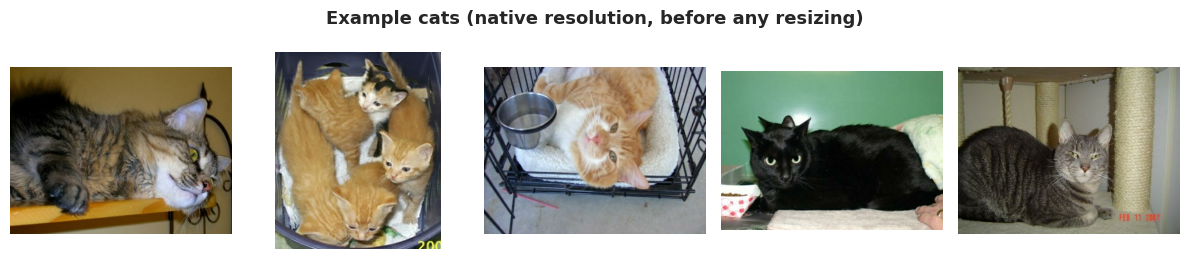

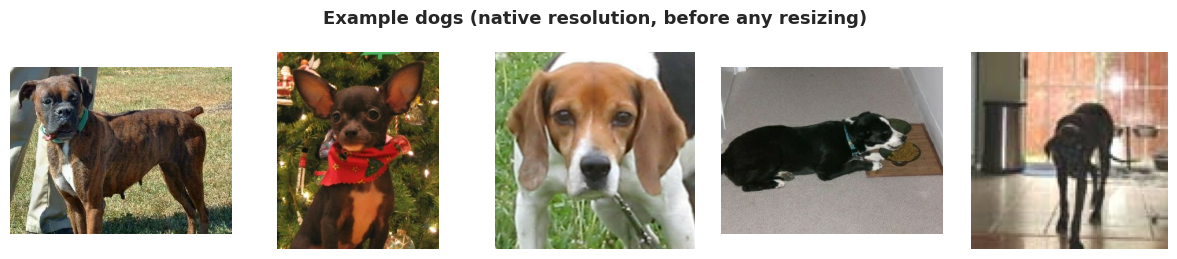

In [4]:
def show_examples_from_ds(ds, n, title):
    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.6))
    for ax, (image, label) in zip(axes, tfds.as_numpy(ds.take(n))):
        ax.imshow(image.astype("uint8"))
        ax.axis("off")
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_examples_from_ds(cats_ds, 5, "Example cats (native resolution, before any resizing)")
show_examples_from_ds(dogs_ds, 5, "Example dogs (native resolution, before any resizing)")

In [5]:
print(f"cats: {N_PER_CLASS}   dogs: {N_PER_CLASS}   "
      f"(balanced by construction — we took exactly {N_PER_CLASS} of each)")

cats: 1500   dogs: 1500   (balanced by construction — we took exactly 1500 of each)


## 3. Splitting Into Train / Validation / Test

In Session 15 we materialized everything into numpy arrays first and used `sklearn`'s `train_test_split`.
This time, since we want to keep images at native resolution until each architecture's own
resize/preprocess step, we do the split **inside `tf.data`** instead: shuffle the whole balanced pool
once with a fixed seed (`reshuffle_each_iteration=False`, so the split is reproducible), then carve it
into three non-overlapping slices with `.take()` / `.skip()`.

This gives every one of the five architectures the *exact same* train/validation/test images — the only
thing that changes between architectures is how those images get resized and preprocessed.

In [6]:
TOTAL_IMAGES = 2 * N_PER_CLASS
N_TRAIN = int(0.70 * TOTAL_IMAGES)
N_VAL = int(0.15 * TOTAL_IMAGES)
N_TEST = TOTAL_IMAGES - N_TRAIN - N_VAL

# reshuffle_each_iteration=False -> the same fixed random order every time this dataset is iterated,
# which is what makes the take()/skip() split below reproducible and identical across architectures
shuffled_ds = raw_balanced_ds.shuffle(buffer_size=TOTAL_IMAGES, seed=SEED, reshuffle_each_iteration=False)

train_raw_ds = shuffled_ds.take(N_TRAIN)
val_raw_ds = shuffled_ds.skip(N_TRAIN).take(N_VAL)
test_raw_ds = shuffled_ds.skip(N_TRAIN + N_VAL).take(N_TEST)

print(f"train: {N_TRAIN} images   val: {N_VAL} images   test: {N_TEST} images")

train: 2100 images   val: 450 images   test: 450 images


## 4. Shared Settings and Plotting/Reporting Helpers

Two things are worth separating clearly before we start:

- **Model-building and training happen fully spelled out, separately, for each architecture below** —
  loading the pretrained backbone, freezing it, attaching a head, compiling, training. The fine-tuning
  model gets exactly the same treatment as its own, separate block of cells: a *fresh* copy of the
  backbone, a *fresh* head, unfrozen from the start, trained on its own. None of that is hidden behind a
  shared function, so you can see exactly what each architecture's code is doing and how the
  transfer-learning cells differ from the fine-tuning cells.
- **Plotting and reporting are generic bookkeeping, not modeling decisions** — exactly like Session 15's
  `plot_training_curves` / `evaluate_model` / `plot_confusion` helpers, we write the *mechanics* of
  "plot every tracked metric" and "evaluate + classification report" once, since that code is identical
  no matter which architecture or phase we're looking at.

`results` and `histories` are the same pattern as Session 15: every architecture's own cells add their
scores and per-epoch history into these two dictionaries by hand, so Section 10 can compare all ten
models at the end.

**On epoch counts:** the transfer-learning model only ever trains a small head on top of frozen
features, which tends to converge quickly. The fine-tuning model trains a *freshly initialized* head
together with part of the backbone at the same time — a harder optimization problem — so we give it a
few more epochs to have a fair chance to catch up.

In [7]:
BATCH_SIZE = 32
EPOCHS_TL = 8      # transfer learning model: frozen backbone + a small head trained from scratch
EPOCHS_FT = 12     # fine-tuning model: partially unfrozen backbone + a fresh head, trained together

results = {}      # every model's final scores, filled in by hand at the end of each architecture's cells
histories = {}    # every model's per-epoch history, same pattern


def plot_all_metrics(history, title):
    metric_names = [k for k in history.history if not k.startswith("val_")]
    n = len(metric_names)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, metric in zip(axes, metric_names):
        ax.plot(history.history[metric], label="train", color="#38BDF8", lw=2)
        val_key = f"val_{metric}"
        if val_key in history.history:
            ax.plot(history.history[val_key], label="validation", color="#F59E0B", lw=2)
        ax.set_title(metric)
        ax.set_xlabel("epoch")
        ax.legend()
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def evaluate_and_report(model, test_ds, title):
    y_test = np.concatenate([y for _, y in tfds.as_numpy(test_ds)])

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"=== {title}: test set ===")
    print(f"loss: {test_loss:.4f}   accuracy: {test_acc:.4f}\n")

    y_pred_prob = model.predict(test_ds, verbose=0).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))
    return y_test, test_loss, test_acc, y_pred, y_pred_prob


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{title} — confusion matrix")
    plt.xlabel("predicted")
    plt.ylabel("actual")
    plt.tight_layout()
    plt.show()

## 5. VGG16

**VGG16** (2014) is the "obvious idea done thoroughly" architecture: nothing but 3x3 convolutions and
2x2 max-pooling, stacked 16 layers deep, with no fancy skip connections or parallel branches. It's
large (~138M parameters, almost all in its fully-connected layers, which we discard here since we only
keep the convolutional base) and slow by modern standards, but its simplicity makes it a good baseline
for "does transfer learning even work here" before trying the more sophisticated architectures.

### 5.1 Resize and preprocess the data for VGG16

In [8]:
IMG_SIZE_VGG = (224, 224)   # VGG16's expected input size

def vgg_preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE_VGG)
    image = keras.applications.vgg16.preprocess_input(image)   # VGG16's own pixel normalization -- NOT plain 0-1 scaling
    return image, label

vgg_train_ds = (
    train_raw_ds
    .map(vgg_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .shuffle(N_TRAIN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
vgg_val_ds = (
    val_raw_ds
    .map(vgg_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
vgg_test_ds = (
    test_raw_ds
    .map(vgg_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

### 5.2 Model 1 — Transfer learning: bring in the pretrained VGG16 backbone and freeze it

In [20]:
vgg_tl_base = keras.applications.VGG16(include_top=False , weights="imagenet",
                                       input_shape=(*IMG_SIZE_VGG,3))
vgg_tl_base.trainable = False
print(f"VG16 layers : {len(vgg_tl_base.layers)} , parametes : {vgg_tl_base.count_params():}")

VG16 layers : 19 , parametes : 14714688


### 5.3 Build the classifier head — same `Sequential` + `Flatten` style as Session 15

Same building block you already know from the Session 15 CNNs: `keras.Sequential([...])`, a stack of
layers listed top to bottom. The only new idea here is that the *first* layer in the stack is the whole
pretrained VGG16 backbone instead of a `Conv2D` — everything after it works exactly like before:
`Flatten` turns its output feature maps into a flat vector, then `Dropout` and a `Dense(1, sigmoid)` do
the actual binary classification.

(`vgg_tl_base.trainable = False`, set above, already tells Keras to keep every one of the backbone's
layers — including its `BatchNormalization` layers — in inference mode and out of training. No extra
step is needed for that here.)

In [23]:
vgg_tl_model = keras.Sequential([
    vgg_tl_base,
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(1,activation='sigmoid')
], name="vgg_transfer")
vgg_tl_model.summary()

Model: "vgg_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        25,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,739,777 (56.23 MB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 5.4 Compile — only the head's weights are trainable

In [27]:
vgg_tl_model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


### 5.5 Train Model 1 (transfer learning)

In [28]:
t0 = time.time()
vgg_tl_history = vgg_tl_model.fit(vgg_train_ds, validation_data=vgg_val_ds,
                                 epochs=EPOCHS_TL, verbose = 2
                                 )
vgg_tl_train_time = time.time() - t0

Epoch 1/8


I0000 00:00:1788947753.283419     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


66/66 - 53s - 806ms/step - accuracy: 0.9057 - loss: 2.1782 - val_accuracy: 0.9644 - val_loss: 0.7251
Epoch 2/8
66/66 - 21s - 319ms/step - accuracy: 0.9886 - loss: 0.1594 - val_accuracy: 0.9644 - val_loss: 0.7018
Epoch 3/8
66/66 - 22s - 326ms/step - accuracy: 0.9943 - loss: 0.0588 - val_accuracy: 0.9689 - val_loss: 0.6783
Epoch 4/8
66/66 - 22s - 330ms/step - accuracy: 0.9957 - loss: 0.0512 - val_accuracy: 0.9600 - val_loss: 0.8222
Epoch 5/8
66/66 - 22s - 326ms/step - accuracy: 0.9948 - loss: 0.0895 - val_accuracy: 0.9622 - val_loss: 1.0141
Epoch 6/8
66/66 - 21s - 324ms/step - accuracy: 0.9938 - loss: 0.0555 - val_accuracy: 0.9644 - val_loss: 0.9491
Epoch 7/8
66/66 - 21s - 319ms/step - accuracy: 0.9971 - loss: 0.0204 - val_accuracy: 0.9644 - val_loss: 1.1109
Epoch 8/8
66/66 - 21s - 323ms/step - accuracy: 0.9971 - loss: 0.0382 - val_accuracy: 0.9578 - val_loss: 1.2317


### 5.6 Training curves — every tracked metric, per epoch

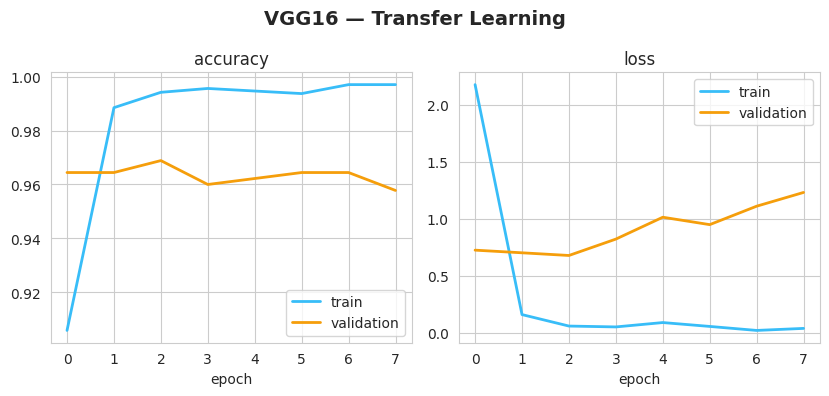

In [29]:

plot_all_metrics(vgg_tl_history, "VGG16 — Transfer Learning")

### 5.7 Evaluate on the test set

In [32]:
vgg_tl_y_test, vgg_tl_loss ,vgg_tl_acc ,vgg_tl_y_pred, vgg_tl_y_prob = evaluate_and_report(
    vgg_tl_model, vgg_test_ds , "vgg tranfer learning"
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


=== vgg tranfer learning: test set ===
loss: 0.6838   accuracy: 0.9733

              precision    recall  f1-score   support

         cat      0.960     0.986     0.973       217
         dog      0.987     0.961     0.974       233

    accuracy                          0.973       450
   macro avg      0.973     0.974     0.973       450
weighted avg      0.974     0.973     0.973       450



### 5.8 Confusion matrix

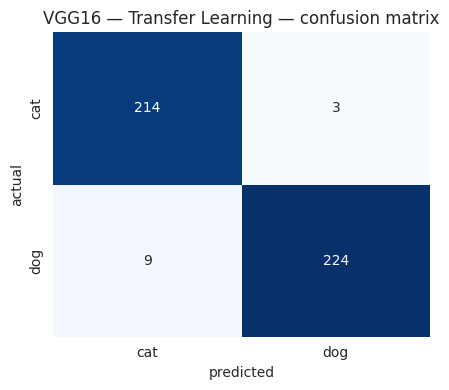

In [33]:
plot_confusion(vgg_tl_y_test, vgg_tl_y_pred, "VGG16 — Transfer Learning")

In [34]:
results["VGG16 (Transfer)"] = dict(
    test_loss=vgg_tl_loss, test_acc=vgg_tl_acc,
    params=vgg_tl_trainable, train_time=vgg_tl_train_time,
)
histories["VGG16 (Transfer)"] = vgg_tl_history

NameError: name 'vgg_tl_trainable' is not defined

**Takeaway.** VGG16's frozen features come from an enormous, generic dataset (ImageNet) that includes
plenty of cats and dogs among its 1,000 categories — so even *without* any fine-tuning, expect this to
already beat every from-scratch CNN from Session 15 by a wide margin.

### 5.9 Model 2 — Fine-tuning: a *fresh*, independent copy of VGG16

This is a **separate model** from Model 1 above — a brand-new copy of the pretrained backbone, and a
brand-new (randomly initialized) classification head. The only difference in how we build it is that we
unfreeze its last 4 layers *before* training even starts, so those layers and the new head
train together from epoch 1.

The simplest way to say "unfreeze just the last few layers": make the whole backbone trainable, then
loop over all *but* the last 4 layers and freeze those back down.

In [42]:
vgg_ft_base = keras.applications.VGG16(include_top=False , weights="imagenet",
                                       input_shape=(*IMG_SIZE_VGG,3))
vgg_ft_base.trainable = True
for layer in vgg_ft_base.layers[:-4]:
    layer.trainable = False
n_trainable_layers = sum(layer.trainable for layer in vgg_ft_base.layers)    
n_trainable_layers

4

### 5.10 Build a *fresh* classifier head — same `Sequential` + `Flatten` style

Same pattern as Model 1's head above: a `Sequential` stack, backbone first, then `Flatten`, `Dropout`,
`Dense(1, sigmoid)`. This is a brand-new, randomly-initialized head — it does not reuse Model 1's trained
weights.

(The freeze/unfreeze loop above already set `.trainable` correctly, layer by layer, on `vgg_ft_base` —
including any `BatchNormalization` layers inside it — so, just like Model 1, no extra step is needed to
keep the still-frozen layers in inference mode.)

In [44]:
vgg_ft_model = keras.Sequential([
    vgg_ft_base,
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(1,activation='sigmoid')
], name="vgg_finetunining")
vgg_ft_model.summary()

Model: "vgg_finetunining"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │        25,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,739,777 (56.23 MB)

 Trainable params: 7,104,513 (27.10 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

### 5.11 Compile — the head AND the unfrozen backbone layers are trainable together

In [45]:
vgg_ft_model.compile(
    optimizer = keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


### 5.12 Train Model 2 (fine-tuning) — independently, for its own {EPOCHS_FT} epochs

In [46]:
t0 = time.time()
vgg_ft_history = vgg_ft_model.fit(vgg_train_ds, validation_data=vgg_val_ds,
                                 epochs=EPOCHS_FT, verbose = 2
                                 )
vgg_ft_train_time = time.time() - t0

Epoch 1/12
66/66 - 32s - 480ms/step - accuracy: 0.8105 - loss: 1.0096 - val_accuracy: 0.9511 - val_loss: 0.1159
Epoch 2/12
66/66 - 23s - 351ms/step - accuracy: 0.9686 - loss: 0.0972 - val_accuracy: 0.9533 - val_loss: 0.1178
Epoch 3/12
66/66 - 23s - 349ms/step - accuracy: 0.9919 - loss: 0.0242 - val_accuracy: 0.9556 - val_loss: 0.1004
Epoch 4/12
66/66 - 23s - 351ms/step - accuracy: 0.9938 - loss: 0.0223 - val_accuracy: 0.9556 - val_loss: 0.1126
Epoch 5/12
66/66 - 23s - 351ms/step - accuracy: 0.9962 - loss: 0.0109 - val_accuracy: 0.9622 - val_loss: 0.1039
Epoch 6/12
66/66 - 23s - 343ms/step - accuracy: 0.9976 - loss: 0.0081 - val_accuracy: 0.9689 - val_loss: 0.0821
Epoch 7/12
66/66 - 23s - 347ms/step - accuracy: 0.9967 - loss: 0.0148 - val_accuracy: 0.9578 - val_loss: 0.1174
Epoch 8/12
66/66 - 23s - 342ms/step - accuracy: 0.9986 - loss: 0.0044 - val_accuracy: 0.9756 - val_loss: 0.0855
Epoch 9/12
66/66 - 23s - 346ms/step - accuracy: 0.9990 - loss: 0.0031 - val_accuracy: 0.9733 - val_loss:

### 5.13 Training curves — every tracked metric, per epoch

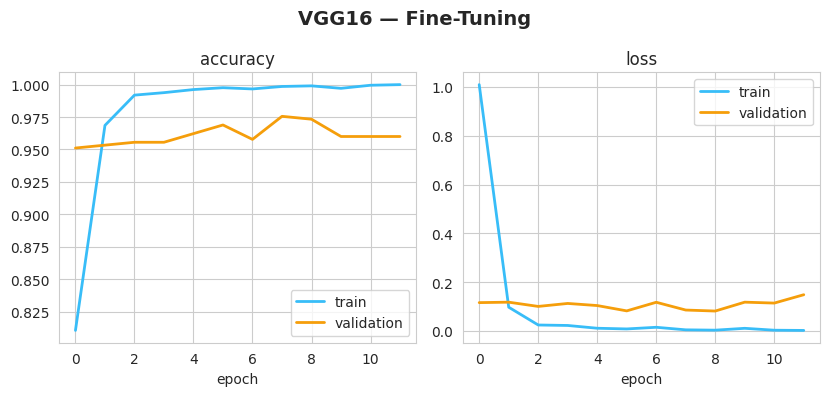

In [47]:
plot_all_metrics(vgg_ft_history, "VGG16 — Fine-Tuning")

### 5.14 Evaluate on the test set

In [48]:
vgg_ft_y_test, vgg_ft_loss ,vgg_ft_acc ,vgg_ft_y_pred, vgg_ft_y_prob = evaluate_and_report(
    vgg_ft_model, vgg_test_ds , "vgg finetuning"
)

=== vgg finetuning: test set ===
loss: 0.1333   accuracy: 0.9800

              precision    recall  f1-score   support

         cat      0.995     0.963     0.979       217
         dog      0.967     0.996     0.981       233

    accuracy                          0.980       450
   macro avg      0.981     0.979     0.980       450
weighted avg      0.980     0.980     0.980       450



### 5.15 Confusion matrix

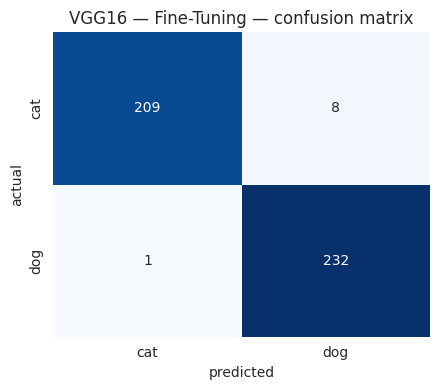

In [49]:
plot_confusion(vgg_ft_y_test, vgg_ft_y_pred, "VGG16 — Fine-Tuning")

In [50]:
results["VGG16 (Fine-tune)"] = dict(
    test_loss=vgg_ft_loss, test_acc=vgg_ft_acc,
    params=vgg_ft_trainable, train_time=vgg_ft_train_time,
)
histories["VGG16 (Fine-tune)"] = vgg_ft_history

NameError: name 'vgg_ft_trainable' is not defined

**Takeaway.** VGG16 has no `BatchNormalization` layers at all (they weren't standard practice yet in
2014), so unfreezing its last few layers only affects `Conv2D` layers directly. Compare this model —
trained independently with part of the backbone unfrozen from the start — against Section 5's frozen
transfer-learning model: did letting those last convolutional filters adapt actually help, or was the
frozen version already good enough?

## 6. ResNet50

**ResNet50** (2015) introduced **residual (skip) connections** — each block adds its input back to its
output, letting gradients flow directly through the network during backpropagation. This solved the
"very deep networks are hard to train" problem and let architectures grow far deeper than before
(50 layers here, and much deeper variants exist). It's a much more efficient use of parameters than
VGG16 (~25M vs. ~138M) despite being deeper.

### 6.1 Resize and preprocess the data for ResNet50

In [ ]:
IMG_SIZE_RESNET = (224, 224)   # ResNet50's expected input size

def resnet_preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE_RESNET)
    image = keras.applications.resnet50.preprocess_input(image)   # ResNet50's own pixel normalization -- NOT plain 0-1 scaling
    return image, label

resnet_train_ds = (
    train_raw_ds
    .map(resnet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .shuffle(N_TRAIN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
resnet_val_ds = (
    val_raw_ds
    .map(resnet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
resnet_test_ds = (
    test_raw_ds
    .map(resnet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

### 6.2 Model 1 — Transfer learning: bring in the pretrained ResNet50 backbone and freeze it

In [ ]:
# TODO: bring in the pretrained ResNet50 backbone and freeze it.
#   - resnet_tl_base = keras.applications.ResNet50(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE_RESNET, 3))
#   - resnet_tl_base.trainable = False   # freeze every layer -- none of these pretrained weights will update
#   - print how many layers the backbone has and how many parameters are frozen
#     (use resnet_tl_base.layers and resnet_tl_base.count_params())

### 6.3 Build the classifier head — same `Sequential` + `Flatten` style as Session 15

Same building block you already know from the Session 15 CNNs: `keras.Sequential([...])`, a stack of
layers listed top to bottom. The only new idea here is that the *first* layer in the stack is the whole
pretrained ResNet50 backbone instead of a `Conv2D` — everything after it works exactly like before:
`Flatten` turns its output feature maps into a flat vector, then `Dropout` and a `Dense(1, sigmoid)` do
the actual binary classification.

(`resnet_tl_base.trainable = False`, set above, already tells Keras to keep every one of the backbone's
layers — including its `BatchNormalization` layers — in inference mode and out of training. No extra
step is needed for that here.)

In [ ]:
# TODO: build resnet_tl_model as a keras.Sequential([...]), same style as Session 15's CNNs:
#   - resnet_tl_base (the backbone you just loaded above) as the first layer in the stack
#   - layers.Flatten()
#   - layers.Dropout(0.3)
#   - layers.Dense(1, activation="sigmoid")
#   - name="resnet_transfer"
#   - call resnet_tl_model.summary() to check the architecture

### 6.4 Compile — only the head's weights are trainable

In [ ]:
# TODO: compile resnet_tl_model.
#   - optimizer=keras.optimizers.Adam(1e-3)
#   - loss="binary_crossentropy"
#   - metrics=["accuracy"]
#   - then compute and print how many trainable parameters it has, e.g.
#     resnet_tl_trainable = int(np.sum([np.prod(w.shape) for w in resnet_tl_model.trainable_weights]))

### 6.5 Train Model 1 (transfer learning)

In [ ]:
# TODO: train resnet_tl_model.
#   - fit on resnet_train_ds, validation_data=resnet_val_ds, epochs=EPOCHS_TL, verbose=2
#   - store the returned History object as resnet_tl_history
#   - time the call (e.g. with time.time()) and store it as resnet_tl_train_time

### 6.6 Training curves — every tracked metric, per epoch

In [ ]:
# TODO: plot resnet_tl_history's training curves.
#   - call plot_all_metrics(resnet_tl_history, "ResNet50 — Transfer Learning")

### 6.7 Evaluate on the test set

In [ ]:
# TODO: evaluate resnet_tl_model on the test set.
#   - call evaluate_and_report(resnet_tl_model, resnet_test_ds, "ResNet50 — Transfer Learning")
#   - unpack its return value into:
#     resnet_tl_y_test, resnet_tl_loss, resnet_tl_acc, resnet_tl_y_pred, resnet_tl_y_prob

### 6.8 Confusion matrix

In [ ]:
# TODO: plot the confusion matrix for Model 1.
#   - call plot_confusion(resnet_tl_y_test, resnet_tl_y_pred, "ResNet50 — Transfer Learning")

In [ ]:
results["ResNet50 (Transfer)"] = dict(
    test_loss=resnet_tl_loss, test_acc=resnet_tl_acc,
    params=resnet_tl_trainable, train_time=resnet_tl_train_time,
)
histories["ResNet50 (Transfer)"] = resnet_tl_history

**Takeaway.** Compare ResNet50's frozen-backbone accuracy and parameter count against VGG16's — a good
architecture often gets you more accuracy *per parameter*, not just more accuracy outright.

### 6.9 Model 2 — Fine-tuning: a *fresh*, independent copy of ResNet50

This is a **separate model** from Model 1 above — a brand-new copy of the pretrained backbone, and a
brand-new (randomly initialized) classification head. The only difference in how we build it is that we
unfreeze its last 35 layers *before* training even starts, so those layers and the new head
train together from epoch 1.

The simplest way to say "unfreeze just the last few layers": make the whole backbone trainable, then
loop over all *but* the last 35 layers and freeze those back down.

In [ ]:
# TODO: bring in a FRESH copy of the ResNet50 backbone and unfreeze just its last 35 layers.
#   - resnet_ft_base = keras.applications.ResNet50(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE_RESNET, 3))
#   - resnet_ft_base.trainable = True                 # start by making every layer trainable...
#   - for layer in resnet_ft_base.layers[:-35]:
#         layer.trainable = False                    # ...then freeze every layer except the last 35
#   - print how many layers the backbone has total and how many are left trainable

### 6.10 Build a *fresh* classifier head — same `Sequential` + `Flatten` style

Same pattern as Model 1's head above: a `Sequential` stack, backbone first, then `Flatten`, `Dropout`,
`Dense(1, sigmoid)`. This is a brand-new, randomly-initialized head — it does not reuse Model 1's trained
weights.

(The freeze/unfreeze loop above already set `.trainable` correctly, layer by layer, on `resnet_ft_base` —
including any `BatchNormalization` layers inside it — so, just like Model 1, no extra step is needed to
keep the still-frozen layers in inference mode.)

In [ ]:
# TODO: build resnet_ft_model as a FRESH keras.Sequential([...]) — same style as Model 1's head above,
#   but do NOT reuse resnet_tl_model's trained weights:
#   - resnet_ft_base (the backbone you just loaded/unfroze above) as the first layer in the stack
#   - layers.Flatten()
#   - layers.Dropout(0.3)
#   - layers.Dense(1, activation="sigmoid")
#   - name="resnet_finetune"
#   - call resnet_ft_model.summary() to check the architecture

### 6.11 Compile — the head AND the unfrozen backbone layers are trainable together

In [ ]:
# TODO: compile resnet_ft_model.
#   - optimizer=keras.optimizers.Adam(1e-4)   # smaller than Model 1's 1e-3 -- protects the pretrained filters
#   - loss="binary_crossentropy"
#   - metrics=["accuracy"]
#   - then compute and print how many trainable parameters it has, e.g.
#     resnet_ft_trainable = int(np.sum([np.prod(w.shape) for w in resnet_ft_model.trainable_weights]))

### 6.12 Train Model 2 (fine-tuning) — independently, for its own {EPOCHS_FT} epochs

In [ ]:
# TODO: train resnet_ft_model.
#   - fit on resnet_train_ds, validation_data=resnet_val_ds, epochs=EPOCHS_FT, verbose=2
#   - store the returned History object as resnet_ft_history
#   - time the call and store it as resnet_ft_train_time

### 6.13 Training curves — every tracked metric, per epoch

In [ ]:
# TODO: plot resnet_ft_history's training curves.
#   - call plot_all_metrics(resnet_ft_history, "ResNet50 — Fine-Tuning")

### 6.14 Evaluate on the test set

In [ ]:
# TODO: evaluate resnet_ft_model on the test set.
#   - call evaluate_and_report(resnet_ft_model, resnet_test_ds, "ResNet50 — Fine-Tuning")
#   - unpack its return value into:
#     resnet_ft_y_test, resnet_ft_loss, resnet_ft_acc, resnet_ft_y_pred, resnet_ft_y_prob

### 6.15 Confusion matrix

In [ ]:
# TODO: plot the confusion matrix for Model 2.
#   - call plot_confusion(resnet_ft_y_test, resnet_ft_y_pred, "ResNet50 — Fine-Tuning")

In [ ]:
results["ResNet50 (Fine-tune)"] = dict(
    test_loss=resnet_ft_loss, test_acc=resnet_ft_acc,
    params=resnet_ft_trainable, train_time=resnet_ft_train_time,
)
histories["ResNet50 (Fine-tune)"] = resnet_ft_history

**Takeaway.** ResNet50 has plenty of `BatchNormalization` layers mixed into its last 35 — a further
refinement some practitioners use is to keep those specifically frozen even while their neighboring
`Conv2D` layers unfreeze, since their running statistics are sensitive to small-batch training. We're
keeping things simple here and unfreezing everything in that last slice together; if this model's
training curve looks unstable, that's a likely reason why.

## 7. InceptionV3

**InceptionV3** (2015) runs several convolution sizes (1x1, 3x3, 5x5) **in parallel** within each block
and concatenates their outputs, instead of picking one kernel size per layer like VGG16 does — the
network gets to use whichever receptive field works best at each stage. It's also the one architecture
here that expects a larger `299x299` input (versus `224x224` for the rest), which is why its
preprocessing cell below uses a different `IMG_SIZE_INCEPTION` instead of the size the other
architectures use.

### 7.1 Resize and preprocess the data for InceptionV3

In [ ]:
IMG_SIZE_INCEPTION = (299, 299)   # InceptionV3's expected input size

def inception_preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE_INCEPTION)
    image = keras.applications.inception_v3.preprocess_input(image)   # InceptionV3's own pixel normalization -- NOT plain 0-1 scaling
    return image, label

inception_train_ds = (
    train_raw_ds
    .map(inception_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .shuffle(N_TRAIN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
inception_val_ds = (
    val_raw_ds
    .map(inception_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
inception_test_ds = (
    test_raw_ds
    .map(inception_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

### 7.2 Model 1 — Transfer learning: bring in the pretrained InceptionV3 backbone and freeze it

In [ ]:
# TODO: bring in the pretrained InceptionV3 backbone and freeze it.
#   - inception_tl_base = keras.applications.InceptionV3(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE_INCEPTION, 3))
#   - inception_tl_base.trainable = False   # freeze every layer -- none of these pretrained weights will update
#   - print how many layers the backbone has and how many parameters are frozen
#     (use inception_tl_base.layers and inception_tl_base.count_params())

### 7.3 Build the classifier head — same `Sequential` + `Flatten` style as Session 15

Same building block you already know from the Session 15 CNNs: `keras.Sequential([...])`, a stack of
layers listed top to bottom. The only new idea here is that the *first* layer in the stack is the whole
pretrained InceptionV3 backbone instead of a `Conv2D` — everything after it works exactly like before:
`Flatten` turns its output feature maps into a flat vector, then `Dropout` and a `Dense(1, sigmoid)` do
the actual binary classification.

(`inception_tl_base.trainable = False`, set above, already tells Keras to keep every one of the backbone's
layers — including its `BatchNormalization` layers — in inference mode and out of training. No extra
step is needed for that here.)

In [ ]:
# TODO: build inception_tl_model as a keras.Sequential([...]), same style as Session 15's CNNs:
#   - inception_tl_base (the backbone you just loaded above) as the first layer in the stack
#   - layers.Flatten()
#   - layers.Dropout(0.3)
#   - layers.Dense(1, activation="sigmoid")
#   - name="inception_transfer"
#   - call inception_tl_model.summary() to check the architecture

### 7.4 Compile — only the head's weights are trainable

In [ ]:
# TODO: compile inception_tl_model.
#   - optimizer=keras.optimizers.Adam(1e-3)
#   - loss="binary_crossentropy"
#   - metrics=["accuracy"]
#   - then compute and print how many trainable parameters it has, e.g.
#     inception_tl_trainable = int(np.sum([np.prod(w.shape) for w in inception_tl_model.trainable_weights]))

### 7.5 Train Model 1 (transfer learning)

In [ ]:
# TODO: train inception_tl_model.
#   - fit on inception_train_ds, validation_data=inception_val_ds, epochs=EPOCHS_TL, verbose=2
#   - store the returned History object as inception_tl_history
#   - time the call (e.g. with time.time()) and store it as inception_tl_train_time

### 7.6 Training curves — every tracked metric, per epoch

In [ ]:
# TODO: plot inception_tl_history's training curves.
#   - call plot_all_metrics(inception_tl_history, "InceptionV3 — Transfer Learning")

### 7.7 Evaluate on the test set

In [ ]:
# TODO: evaluate inception_tl_model on the test set.
#   - call evaluate_and_report(inception_tl_model, inception_test_ds, "InceptionV3 — Transfer Learning")
#   - unpack its return value into:
#     inception_tl_y_test, inception_tl_loss, inception_tl_acc, inception_tl_y_pred, inception_tl_y_prob

### 7.8 Confusion matrix

In [ ]:
# TODO: plot the confusion matrix for Model 1.
#   - call plot_confusion(inception_tl_y_test, inception_tl_y_pred, "InceptionV3 — Transfer Learning")

In [ ]:
results["InceptionV3 (Transfer)"] = dict(
    test_loss=inception_tl_loss, test_acc=inception_tl_acc,
    params=inception_tl_trainable, train_time=inception_tl_train_time,
)
histories["InceptionV3 (Transfer)"] = inception_tl_history

**Takeaway.** InceptionV3 sees images at roughly 1.75x the resolution of the other four architectures —
worth keeping in mind if its results differ noticeably; that's a genuinely different amount of visual
detail per image, not just a different backbone.

### 7.9 Model 2 — Fine-tuning: a *fresh*, independent copy of InceptionV3

This is a **separate model** from Model 1 above — a brand-new copy of the pretrained backbone, and a
brand-new (randomly initialized) classification head. The only difference in how we build it is that we
unfreeze its last 60 layers *before* training even starts, so those layers and the new head
train together from epoch 1.

The simplest way to say "unfreeze just the last few layers": make the whole backbone trainable, then
loop over all *but* the last 60 layers and freeze those back down.

In [ ]:
# TODO: bring in a FRESH copy of the InceptionV3 backbone and unfreeze just its last 60 layers.
#   - inception_ft_base = keras.applications.InceptionV3(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE_INCEPTION, 3))
#   - inception_ft_base.trainable = True                 # start by making every layer trainable...
#   - for layer in inception_ft_base.layers[:-60]:
#         layer.trainable = False                    # ...then freeze every layer except the last 60
#   - print how many layers the backbone has total and how many are left trainable

### 7.10 Build a *fresh* classifier head — same `Sequential` + `Flatten` style

Same pattern as Model 1's head above: a `Sequential` stack, backbone first, then `Flatten`, `Dropout`,
`Dense(1, sigmoid)`. This is a brand-new, randomly-initialized head — it does not reuse Model 1's trained
weights.

(The freeze/unfreeze loop above already set `.trainable` correctly, layer by layer, on `inception_ft_base` —
including any `BatchNormalization` layers inside it — so, just like Model 1, no extra step is needed to
keep the still-frozen layers in inference mode.)

In [ ]:
# TODO: build inception_ft_model as a FRESH keras.Sequential([...]) — same style as Model 1's head above,
#   but do NOT reuse inception_tl_model's trained weights:
#   - inception_ft_base (the backbone you just loaded/unfroze above) as the first layer in the stack
#   - layers.Flatten()
#   - layers.Dropout(0.3)
#   - layers.Dense(1, activation="sigmoid")
#   - name="inception_finetune"
#   - call inception_ft_model.summary() to check the architecture

### 7.11 Compile — the head AND the unfrozen backbone layers are trainable together

In [ ]:
# TODO: compile inception_ft_model.
#   - optimizer=keras.optimizers.Adam(1e-4)   # smaller than Model 1's 1e-3 -- protects the pretrained filters
#   - loss="binary_crossentropy"
#   - metrics=["accuracy"]
#   - then compute and print how many trainable parameters it has, e.g.
#     inception_ft_trainable = int(np.sum([np.prod(w.shape) for w in inception_ft_model.trainable_weights]))

### 7.12 Train Model 2 (fine-tuning) — independently, for its own {EPOCHS_FT} epochs

In [ ]:
# TODO: train inception_ft_model.
#   - fit on inception_train_ds, validation_data=inception_val_ds, epochs=EPOCHS_FT, verbose=2
#   - store the returned History object as inception_ft_history
#   - time the call and store it as inception_ft_train_time

### 7.13 Training curves — every tracked metric, per epoch

In [ ]:
# TODO: plot inception_ft_history's training curves.
#   - call plot_all_metrics(inception_ft_history, "InceptionV3 — Fine-Tuning")

### 7.14 Evaluate on the test set

In [ ]:
# TODO: evaluate inception_ft_model on the test set.
#   - call evaluate_and_report(inception_ft_model, inception_test_ds, "InceptionV3 — Fine-Tuning")
#   - unpack its return value into:
#     inception_ft_y_test, inception_ft_loss, inception_ft_acc, inception_ft_y_pred, inception_ft_y_prob

### 7.15 Confusion matrix

In [ ]:
# TODO: plot the confusion matrix for Model 2.
#   - call plot_confusion(inception_ft_y_test, inception_ft_y_pred, "InceptionV3 — Fine-Tuning")

In [ ]:
results["InceptionV3 (Fine-tune)"] = dict(
    test_loss=inception_ft_loss, test_acc=inception_ft_acc,
    params=inception_ft_trainable, train_time=inception_ft_train_time,
)
histories["InceptionV3 (Fine-tune)"] = inception_ft_history

**Takeaway.** With 311 layers, InceptionV3 is the deepest backbone in this notebook — unfreezing its
last 60 layers is still a sizeable trainable chunk. Check whether that much capacity to fine-tune helped
this independently-trained model more than the extra epochs alone would explain, or whether it started
overfitting our fairly small training set.

## 8. MobileNetV2

**MobileNetV2** (2018) was designed for phones and other resource-constrained devices, using
**depthwise-separable convolutions** — splitting a standard convolution into a much cheaper "filter each
channel separately, then mix channels" pair of steps. The result is a fraction of the parameters and
compute of the other architectures here (~3.5M vs. tens of millions), aimed at running fast on a device
with no GPU rather than squeezing out the last percent of accuracy.

### 8.1 Resize and preprocess the data for MobileNetV2

In [ ]:
IMG_SIZE_MOBILENET = (224, 224)   # MobileNetV2's expected input size

def mobilenet_preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE_MOBILENET)
    image = keras.applications.mobilenet_v2.preprocess_input(image)   # MobileNetV2's own pixel normalization -- NOT plain 0-1 scaling
    return image, label

mobilenet_train_ds = (
    train_raw_ds
    .map(mobilenet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .shuffle(N_TRAIN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
mobilenet_val_ds = (
    val_raw_ds
    .map(mobilenet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
mobilenet_test_ds = (
    test_raw_ds
    .map(mobilenet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

### 8.2 Model 1 — Transfer learning: bring in the pretrained MobileNetV2 backbone and freeze it

In [ ]:
# TODO: bring in the pretrained MobileNetV2 backbone and freeze it.
#   - mobilenet_tl_base = keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE_MOBILENET, 3))
#   - mobilenet_tl_base.trainable = False   # freeze every layer -- none of these pretrained weights will update
#   - print how many layers the backbone has and how many parameters are frozen
#     (use mobilenet_tl_base.layers and mobilenet_tl_base.count_params())

### 8.3 Build the classifier head — same `Sequential` + `Flatten` style as Session 15

Same building block you already know from the Session 15 CNNs: `keras.Sequential([...])`, a stack of
layers listed top to bottom. The only new idea here is that the *first* layer in the stack is the whole
pretrained MobileNetV2 backbone instead of a `Conv2D` — everything after it works exactly like before:
`Flatten` turns its output feature maps into a flat vector, then `Dropout` and a `Dense(1, sigmoid)` do
the actual binary classification.

(`mobilenet_tl_base.trainable = False`, set above, already tells Keras to keep every one of the backbone's
layers — including its `BatchNormalization` layers — in inference mode and out of training. No extra
step is needed for that here.)

In [ ]:
# TODO: build mobilenet_tl_model as a keras.Sequential([...]), same style as Session 15's CNNs:
#   - mobilenet_tl_base (the backbone you just loaded above) as the first layer in the stack
#   - layers.Flatten()
#   - layers.Dropout(0.3)
#   - layers.Dense(1, activation="sigmoid")
#   - name="mobilenet_transfer"
#   - call mobilenet_tl_model.summary() to check the architecture

### 8.4 Compile — only the head's weights are trainable

In [ ]:
# TODO: compile mobilenet_tl_model.
#   - optimizer=keras.optimizers.Adam(1e-3)
#   - loss="binary_crossentropy"
#   - metrics=["accuracy"]
#   - then compute and print how many trainable parameters it has, e.g.
#     mobilenet_tl_trainable = int(np.sum([np.prod(w.shape) for w in mobilenet_tl_model.trainable_weights]))

### 8.5 Train Model 1 (transfer learning)

In [ ]:
# TODO: train mobilenet_tl_model.
#   - fit on mobilenet_train_ds, validation_data=mobilenet_val_ds, epochs=EPOCHS_TL, verbose=2
#   - store the returned History object as mobilenet_tl_history
#   - time the call (e.g. with time.time()) and store it as mobilenet_tl_train_time

### 8.6 Training curves — every tracked metric, per epoch

In [ ]:
# TODO: plot mobilenet_tl_history's training curves.
#   - call plot_all_metrics(mobilenet_tl_history, "MobileNetV2 — Transfer Learning")

### 8.7 Evaluate on the test set

In [ ]:
# TODO: evaluate mobilenet_tl_model on the test set.
#   - call evaluate_and_report(mobilenet_tl_model, mobilenet_test_ds, "MobileNetV2 — Transfer Learning")
#   - unpack its return value into:
#     mobilenet_tl_y_test, mobilenet_tl_loss, mobilenet_tl_acc, mobilenet_tl_y_pred, mobilenet_tl_y_prob

### 8.8 Confusion matrix

In [ ]:
# TODO: plot the confusion matrix for Model 1.
#   - call plot_confusion(mobilenet_tl_y_test, mobilenet_tl_y_pred, "MobileNetV2 — Transfer Learning")

In [ ]:
results["MobileNetV2 (Transfer)"] = dict(
    test_loss=mobilenet_tl_loss, test_acc=mobilenet_tl_acc,
    params=mobilenet_tl_trainable, train_time=mobilenet_tl_train_time,
)
histories["MobileNetV2 (Transfer)"] = mobilenet_tl_history

**Takeaway.** This is the efficiency question in miniature: does MobileNetV2 give up much accuracy
compared to the much larger VGG16/ResNet50/InceptionV3, or does it hold its own with a fraction of the
parameters? That trade-off is exactly why it exists.

### 8.9 Model 2 — Fine-tuning: a *fresh*, independent copy of MobileNetV2

This is a **separate model** from Model 1 above — a brand-new copy of the pretrained backbone, and a
brand-new (randomly initialized) classification head. The only difference in how we build it is that we
unfreeze its last 30 layers *before* training even starts, so those layers and the new head
train together from epoch 1.

The simplest way to say "unfreeze just the last few layers": make the whole backbone trainable, then
loop over all *but* the last 30 layers and freeze those back down.

In [ ]:
# TODO: bring in a FRESH copy of the MobileNetV2 backbone and unfreeze just its last 30 layers.
#   - mobilenet_ft_base = keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE_MOBILENET, 3))
#   - mobilenet_ft_base.trainable = True                 # start by making every layer trainable...
#   - for layer in mobilenet_ft_base.layers[:-30]:
#         layer.trainable = False                    # ...then freeze every layer except the last 30
#   - print how many layers the backbone has total and how many are left trainable

### 8.10 Build a *fresh* classifier head — same `Sequential` + `Flatten` style

Same pattern as Model 1's head above: a `Sequential` stack, backbone first, then `Flatten`, `Dropout`,
`Dense(1, sigmoid)`. This is a brand-new, randomly-initialized head — it does not reuse Model 1's trained
weights.

(The freeze/unfreeze loop above already set `.trainable` correctly, layer by layer, on `mobilenet_ft_base` —
including any `BatchNormalization` layers inside it — so, just like Model 1, no extra step is needed to
keep the still-frozen layers in inference mode.)

In [ ]:
# TODO: build mobilenet_ft_model as a FRESH keras.Sequential([...]) — same style as Model 1's head above,
#   but do NOT reuse mobilenet_tl_model's trained weights:
#   - mobilenet_ft_base (the backbone you just loaded/unfroze above) as the first layer in the stack
#   - layers.Flatten()
#   - layers.Dropout(0.3)
#   - layers.Dense(1, activation="sigmoid")
#   - name="mobilenet_finetune"
#   - call mobilenet_ft_model.summary() to check the architecture

### 8.11 Compile — the head AND the unfrozen backbone layers are trainable together

In [ ]:
# TODO: compile mobilenet_ft_model.
#   - optimizer=keras.optimizers.Adam(1e-4)   # smaller than Model 1's 1e-3 -- protects the pretrained filters
#   - loss="binary_crossentropy"
#   - metrics=["accuracy"]
#   - then compute and print how many trainable parameters it has, e.g.
#     mobilenet_ft_trainable = int(np.sum([np.prod(w.shape) for w in mobilenet_ft_model.trainable_weights]))

### 8.12 Train Model 2 (fine-tuning) — independently, for its own {EPOCHS_FT} epochs

In [ ]:
# TODO: train mobilenet_ft_model.
#   - fit on mobilenet_train_ds, validation_data=mobilenet_val_ds, epochs=EPOCHS_FT, verbose=2
#   - store the returned History object as mobilenet_ft_history
#   - time the call and store it as mobilenet_ft_train_time

### 8.13 Training curves — every tracked metric, per epoch

In [ ]:
# TODO: plot mobilenet_ft_history's training curves.
#   - call plot_all_metrics(mobilenet_ft_history, "MobileNetV2 — Fine-Tuning")

### 8.14 Evaluate on the test set

In [ ]:
# TODO: evaluate mobilenet_ft_model on the test set.
#   - call evaluate_and_report(mobilenet_ft_model, mobilenet_test_ds, "MobileNetV2 — Fine-Tuning")
#   - unpack its return value into:
#     mobilenet_ft_y_test, mobilenet_ft_loss, mobilenet_ft_acc, mobilenet_ft_y_pred, mobilenet_ft_y_prob

### 8.15 Confusion matrix

In [ ]:
# TODO: plot the confusion matrix for Model 2.
#   - call plot_confusion(mobilenet_ft_y_test, mobilenet_ft_y_pred, "MobileNetV2 — Fine-Tuning")

In [ ]:
results["MobileNetV2 (Fine-tune)"] = dict(
    test_loss=mobilenet_ft_loss, test_acc=mobilenet_ft_acc,
    params=mobilenet_ft_trainable, train_time=mobilenet_ft_train_time,
)
histories["MobileNetV2 (Fine-tune)"] = mobilenet_ft_history

**Takeaway.** MobileNetV2's depthwise-separable blocks are more tightly coupled than a standard ResNet
block — small, efficient architectures sometimes have less "slack" to improve from unfreezing part of
the backbone than larger, more redundant ones. Check whether that holds here.

## 9. EfficientNetB0

**EfficientNetB0** (2019) is the newest architecture in this lineup. Rather than hand-designing depth,
width, and input resolution separately (as earlier architectures did), its authors searched for the best
way to scale all three *together*, then used that recipe to produce a whole family of models
(B0 through B7) at different size/accuracy trade-offs. B0 is the smallest member of that family —
still competitive with much larger, older architectures despite its modest size.

### 9.1 Resize and preprocess the data for EfficientNetB0

In [ ]:
IMG_SIZE_EFFNET = (224, 224)   # EfficientNetB0's expected input size

def effnet_preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE_EFFNET)
    image = keras.applications.efficientnet.preprocess_input(image)   # EfficientNetB0's own pixel normalization -- NOT plain 0-1 scaling
    return image, label

effnet_train_ds = (
    train_raw_ds
    .map(effnet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .shuffle(N_TRAIN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
effnet_val_ds = (
    val_raw_ds
    .map(effnet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
effnet_test_ds = (
    test_raw_ds
    .map(effnet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .ignore_errors()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

### 9.2 Model 1 — Transfer learning: bring in the pretrained EfficientNetB0 backbone and freeze it

In [ ]:
# TODO: bring in the pretrained EfficientNetB0 backbone and freeze it.
#   - effnet_tl_base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE_EFFNET, 3))
#   - effnet_tl_base.trainable = False   # freeze every layer -- none of these pretrained weights will update
#   - print how many layers the backbone has and how many parameters are frozen
#     (use effnet_tl_base.layers and effnet_tl_base.count_params())

### 9.3 Build the classifier head — same `Sequential` + `Flatten` style as Session 15

Same building block you already know from the Session 15 CNNs: `keras.Sequential([...])`, a stack of
layers listed top to bottom. The only new idea here is that the *first* layer in the stack is the whole
pretrained EfficientNetB0 backbone instead of a `Conv2D` — everything after it works exactly like before:
`Flatten` turns its output feature maps into a flat vector, then `Dropout` and a `Dense(1, sigmoid)` do
the actual binary classification.

(`effnet_tl_base.trainable = False`, set above, already tells Keras to keep every one of the backbone's
layers — including its `BatchNormalization` layers — in inference mode and out of training. No extra
step is needed for that here.)

In [ ]:
# TODO: build effnet_tl_model as a keras.Sequential([...]), same style as Session 15's CNNs:
#   - effnet_tl_base (the backbone you just loaded above) as the first layer in the stack
#   - layers.Flatten()
#   - layers.Dropout(0.3)
#   - layers.Dense(1, activation="sigmoid")
#   - name="effnet_transfer"
#   - call effnet_tl_model.summary() to check the architecture

### 9.4 Compile — only the head's weights are trainable

In [ ]:
# TODO: compile effnet_tl_model.
#   - optimizer=keras.optimizers.Adam(1e-3)
#   - loss="binary_crossentropy"
#   - metrics=["accuracy"]
#   - then compute and print how many trainable parameters it has, e.g.
#     effnet_tl_trainable = int(np.sum([np.prod(w.shape) for w in effnet_tl_model.trainable_weights]))

### 9.5 Train Model 1 (transfer learning)

In [ ]:
# TODO: train effnet_tl_model.
#   - fit on effnet_train_ds, validation_data=effnet_val_ds, epochs=EPOCHS_TL, verbose=2
#   - store the returned History object as effnet_tl_history
#   - time the call (e.g. with time.time()) and store it as effnet_tl_train_time

### 9.6 Training curves — every tracked metric, per epoch

In [ ]:
# TODO: plot effnet_tl_history's training curves.
#   - call plot_all_metrics(effnet_tl_history, "EfficientNetB0 — Transfer Learning")

### 9.7 Evaluate on the test set

In [ ]:
# TODO: evaluate effnet_tl_model on the test set.
#   - call evaluate_and_report(effnet_tl_model, effnet_test_ds, "EfficientNetB0 — Transfer Learning")
#   - unpack its return value into:
#     effnet_tl_y_test, effnet_tl_loss, effnet_tl_acc, effnet_tl_y_pred, effnet_tl_y_prob

### 9.8 Confusion matrix

In [ ]:
# TODO: plot the confusion matrix for Model 1.
#   - call plot_confusion(effnet_tl_y_test, effnet_tl_y_pred, "EfficientNetB0 — Transfer Learning")

In [ ]:
results["EfficientNetB0 (Transfer)"] = dict(
    test_loss=effnet_tl_loss, test_acc=effnet_tl_acc,
    params=effnet_tl_trainable, train_time=effnet_tl_train_time,
)
histories["EfficientNetB0 (Transfer)"] = effnet_tl_history

**Takeaway.** EfficientNetB0 is from 2019, four to five years newer than the other architectures here —
see whether "newer" translates into "better transfer learning result" on this particular task, or
whether the gap has more to do with parameter count and depth than release date.

### 9.9 Model 2 — Fine-tuning: a *fresh*, independent copy of EfficientNetB0

This is a **separate model** from Model 1 above — a brand-new copy of the pretrained backbone, and a
brand-new (randomly initialized) classification head. The only difference in how we build it is that we
unfreeze its last 45 layers *before* training even starts, so those layers and the new head
train together from epoch 1.

The simplest way to say "unfreeze just the last few layers": make the whole backbone trainable, then
loop over all *but* the last 45 layers and freeze those back down.

In [ ]:
# TODO: bring in a FRESH copy of the EfficientNetB0 backbone and unfreeze just its last 45 layers.
#   - effnet_ft_base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE_EFFNET, 3))
#   - effnet_ft_base.trainable = True                 # start by making every layer trainable...
#   - for layer in effnet_ft_base.layers[:-45]:
#         layer.trainable = False                    # ...then freeze every layer except the last 45
#   - print how many layers the backbone has total and how many are left trainable

### 9.10 Build a *fresh* classifier head — same `Sequential` + `Flatten` style

Same pattern as Model 1's head above: a `Sequential` stack, backbone first, then `Flatten`, `Dropout`,
`Dense(1, sigmoid)`. This is a brand-new, randomly-initialized head — it does not reuse Model 1's trained
weights.

(The freeze/unfreeze loop above already set `.trainable` correctly, layer by layer, on `effnet_ft_base` —
including any `BatchNormalization` layers inside it — so, just like Model 1, no extra step is needed to
keep the still-frozen layers in inference mode.)

In [ ]:
# TODO: build effnet_ft_model as a FRESH keras.Sequential([...]) — same style as Model 1's head above,
#   but do NOT reuse effnet_tl_model's trained weights:
#   - effnet_ft_base (the backbone you just loaded/unfroze above) as the first layer in the stack
#   - layers.Flatten()
#   - layers.Dropout(0.3)
#   - layers.Dense(1, activation="sigmoid")
#   - name="effnet_finetune"
#   - call effnet_ft_model.summary() to check the architecture

### 9.11 Compile — the head AND the unfrozen backbone layers are trainable together

In [ ]:
# TODO: compile effnet_ft_model.
#   - optimizer=keras.optimizers.Adam(1e-4)   # smaller than Model 1's 1e-3 -- protects the pretrained filters
#   - loss="binary_crossentropy"
#   - metrics=["accuracy"]
#   - then compute and print how many trainable parameters it has, e.g.
#     effnet_ft_trainable = int(np.sum([np.prod(w.shape) for w in effnet_ft_model.trainable_weights]))

### 9.12 Train Model 2 (fine-tuning) — independently, for its own {EPOCHS_FT} epochs

In [ ]:
# TODO: train effnet_ft_model.
#   - fit on effnet_train_ds, validation_data=effnet_val_ds, epochs=EPOCHS_FT, verbose=2
#   - store the returned History object as effnet_ft_history
#   - time the call and store it as effnet_ft_train_time

### 9.13 Training curves — every tracked metric, per epoch

In [ ]:
# TODO: plot effnet_ft_history's training curves.
#   - call plot_all_metrics(effnet_ft_history, "EfficientNetB0 — Fine-Tuning")

### 9.14 Evaluate on the test set

In [ ]:
# TODO: evaluate effnet_ft_model on the test set.
#   - call evaluate_and_report(effnet_ft_model, effnet_test_ds, "EfficientNetB0 — Fine-Tuning")
#   - unpack its return value into:
#     effnet_ft_y_test, effnet_ft_loss, effnet_ft_acc, effnet_ft_y_pred, effnet_ft_y_prob

### 9.15 Confusion matrix

In [ ]:
# TODO: plot the confusion matrix for Model 2.
#   - call plot_confusion(effnet_ft_y_test, effnet_ft_y_pred, "EfficientNetB0 — Fine-Tuning")

In [ ]:
results["EfficientNetB0 (Fine-tune)"] = dict(
    test_loss=effnet_ft_loss, test_acc=effnet_ft_acc,
    params=effnet_ft_trainable, train_time=effnet_ft_train_time,
)
histories["EfficientNetB0 (Fine-tune)"] = effnet_ft_history

**Takeaway.** EfficientNet's blocks are more sensitive to learning rate than older architectures (part of
why the original paper pairs it with a carefully tuned training recipe) — if this fine-tuning model
trained less smoothly than the others, a smaller learning rate than `1e-4` is a reasonable first thing
to try.

## 10. Comparing All Ten Models

Time to put every version — all five architectures, transfer learning and fine-tuned, each trained as
its own independent model — side by side.

In [ ]:
comparison = pd.DataFrame(results).T
comparison.index.name = "model"
comparison["test_acc"] = comparison["test_acc"].round(4)
comparison["test_loss"] = comparison["test_loss"].round(4)
comparison["params"] = comparison["params"].astype(int)
comparison["train_time"] = comparison["train_time"].round(1)
comparison = comparison[["test_acc", "test_loss", "params", "train_time"]]
comparison.columns = ["test accuracy", "test loss", "# trainable params", "train time (s)"]
comparison.sort_values("test accuracy", ascending=False)

In [ ]:
arch_names = ["VGG16", "ResNet50", "InceptionV3", "MobileNetV2", "EfficientNetB0"]
transfer_acc = [comparison.loc[f"{n} (Transfer)", "test accuracy"] for n in arch_names]
finetune_acc = [comparison.loc[f"{n} (Fine-tune)", "test accuracy"] for n in arch_names]

x = np.arange(len(arch_names))
width = 0.35

plt.figure(figsize=(11, 5))
bars1 = plt.bar(x - width / 2, transfer_acc, width, label="Transfer learning (Model 1)", color="#38BDF8")
bars2 = plt.bar(x + width / 2, finetune_acc, width, label="Fine-tuned (Model 2)", color="#F59E0B")
for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.1%}", ha="center", fontsize=9, fontweight="bold")

plt.xticks(x, arch_names)
plt.ylim(0, 1.05)
plt.ylabel("test accuracy")
plt.title("Transfer learning vs. fine-tuning, by architecture (two independently trained models each)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(11, 6))
palette = ["#94A3B8", "#38BDF8", "#14B8A6", "#8B5CF6", "#EC4899", "#22C55E", "#F59E0B", "#EF4444", "#0EA5E9", "#A3E635"]
for (name, history), color in zip(histories.items(), palette):
    plt.plot(history.history["val_accuracy"], label=name, color=color, lw=2)
plt.title("Validation accuracy per epoch — all ten models overlaid")
plt.xlabel("epoch (each model trained independently, from epoch 0)")
plt.ylabel("validation accuracy")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### Wrapping up

Read the comparison table and charts together and ask:

- **Did every architecture's transfer-learning model beat Session 15's from-scratch CNNs (which topped
  out around 72% test accuracy)?** If transfer learning doesn't at least match that with a *frozen*
  backbone, something is off with the preprocessing for that architecture — it's worth double-checking
  first.
- **Did the independently-trained fine-tuning model beat its architecture's transfer-learning model, or
  only some of them?** Since these are two separately trained models (not one continued into the other),
  a win here means "unfreezing part of the backbone from the start and training it together with a fresh
  head, for more epochs, was worth the extra risk and compute" — not automatic, especially on a training
  set this small.
- **How do the architectures compare on accuracy *per parameter*, not just raw accuracy?** MobileNetV2 in
  particular is worth judging by this standard, since raw accuracy was never its design goal.
- **Which model would you actually ship?** Exactly like Session 15's final comparison, the answer depends
  on what you're optimizing for: raw accuracy, inference speed and model size (mobile deployment), or
  training time and cost.

This is also a good moment to revisit Session 15's bonus section, where our best from-scratch CNN scored
close to a coin flip on the unrelated malaria dataset. If you have time, try zero-shot evaluating one of
today's fine-tuned models on that same malaria data (no retraining) — does a pretrained backbone's
"knowledge" transfer any better to a completely unrelated domain than a from-scratch CNN's did, or does
that same wall show up again? (Spoiler: cats-vs-dogs and blood-cell microscopy are still very different
domains — pretraining helps *within* related visual domains far more than it helps *across* unrelated
ones.)